In [194]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from nltk.corpus import stopwords
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
#nltk.download('vader_lexicon')
#nltk.download('stopwords')

tweets_df = pd.read_csv("https://raw.githubusercontent.com/KCristopher/SentimentAnalysis/main/sts_gold_tweet.csv")
tweets_df.head()

,id,polarity,tweet
0,1467933112,0,the angel is going to miss the athlete this we...
1,2323395086,0,It looks as though Shaq is getting traded to C...
2,1467968979,0,@clarianne APRIL 9TH ISN'T COMING SOON ENOUGH
3,1990283756,0,drinking a McDonalds coffee and not understand...
4,1988884918,0,So dissapointed Taylor Swift doesnt have a Twi...


In [128]:
tweets_df.shape

(2034, 3)

In [129]:
tweets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2034 entries, 0 to 2033
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        2034 non-null   int64 
 1   polarity  2034 non-null   int64 
 2   tweet     2034 non-null   object
dtypes: int64(2), object(1)
memory usage: 47.8+ KB


In [130]:
tweets_df['id'].nunique(), len(tweets_df)

(2034, 2034)

In [131]:
tweets_df.groupby('id')['tweet'].nunique().sort_values(ascending = False).head(10)

id
1467812416    1
2052262229    1
2053125094    1
2053014136    1
2052945734    1
2052940465    1
2052939840    1
2052859663    1
2052844839    1
2052807447    1
Name: tweet, dtype: int64

In [132]:
( tweets_df.groupby('id')['tweet'].nunique() == 1 ).all()

True

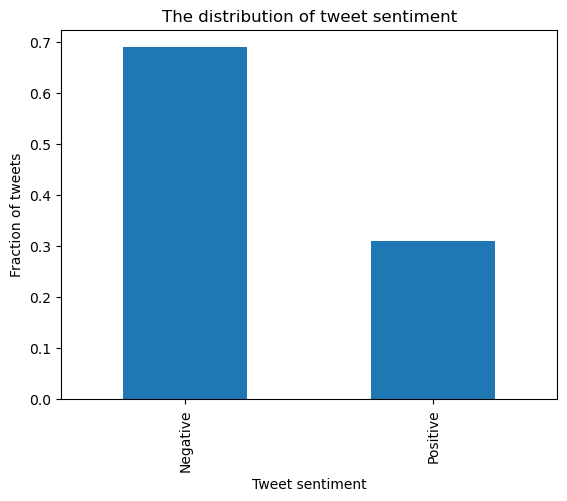

In [133]:
ax = tweets_df['polarity'].value_counts(dropna = False, normalize = True).plot.bar()
plt.title("The distribution of tweet sentiment")
plt.xticks(ax.get_xticks(), ['Negative', 'Positive'])
plt.ylabel('Fraction of tweets')
plt.xlabel('Tweet sentiment')
plt.show()

In [134]:
tweets_df['polarity'].value_counts(dropna = False, normalize = False)

0    1402
4     632
Name: polarity, dtype: int64

In [135]:
sample_tweets = tweets_df[['polarity', 'tweet']].sample(n = 10)

for row in sample_tweets.iterrows() :
    print('\n', row[1]['tweet'], '  >>>>>>>  ', row[1]['polarity'], '\n')


 @nicolerichie YES! lol...when you live in canada, anne part of your childhood. I grew up with all the books and tv series    >>>>>>>   4 


 Those who picked the Cavs are so awwwwfully quiet now!  Nananana....nananana....hey hey....goodbye!   >>>>>>>   4 


 @StaceeyLeigh He lives in Seattle I think  TOO FAR AWAY   >>>>>>>   0 


 @KevChoice I just don't get it. What in a persons mind could even have them on some ish like this???  My prayers are with her fam for real   >>>>>>>   0 


 @billyraycyrus  heey, brazil loves you and miley    >>>>>>>   4 


 today sucked. I'm gonna die without chris and callum!  wahhh!   >>>>>>>   0 


 Trimmed the fat on Safari Sketch . . . runs on the iPhone . . . slowly  . . . time to optimize draw calls.   >>>>>>>   0 


 Brazilian keratin treatment apparently means no washing your hair for 4 days. It's only day two and I'm already stringy and greaser gross    >>>>>>>   0 


 has a stupid stomach ache and fever    >>>>>>>   0 


 I'm sad the Cavs won be

In [136]:
tweets_df['tweet_length'] = tweets_df['tweet'].str.len()
tweets_df['tweet_length'].describe().round(2)

count    2034.00
mean       80.81
std        35.36
min        11.00
25%        51.00
50%        77.50
75%       111.00
max       148.00
Name: tweet_length, dtype: float64

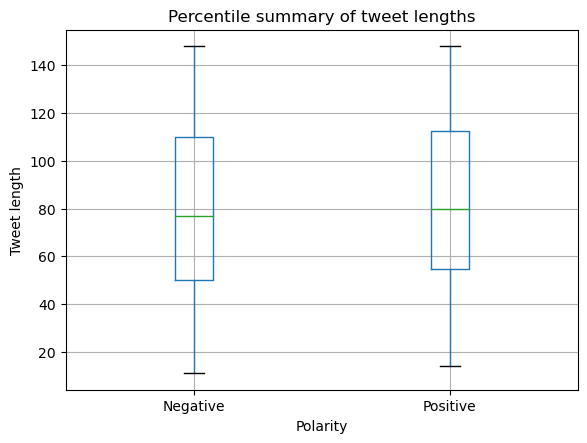

In [137]:
lengths_box = tweets_df.boxplot(column='tweet_length', by='polarity')
plt.suptitle('')
plt.title('Percentile summary of tweet lengths')
plt.xticks( lengths_box.get_xticks(), [ 'Negative', 'Positive' ] )
plt.ylabel('Tweet length')
plt.xlabel('Polarity')

plt.show()

In [138]:
tweets_df.set_index('id', inplace = True)
tweets_df.head()

,polarity,tweet,tweet_length
id,,,
1467933112,0,the angel is going to miss the athlete this we...,52
2323395086,0,It looks as though Shaq is getting traded to C...,126
1467968979,0,@clarianne APRIL 9TH ISN'T COMING SOON ENOUGH,46
1990283756,0,drinking a McDonalds coffee and not understand...,100
1988884918,0,So dissapointed Taylor Swift doesnt have a Twi...,51


In [139]:
y = tweets_df['polarity']
X = tweets_df.drop('polarity', axis = 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

trainset = pd.concat( [ X_train, y_train ], axis = 1  )
testset = pd.concat( [ X_test, y_test ], axis = 1  )

In [140]:
trainset.shape, testset.shape

((1362, 3), (672, 3))

In [141]:
trainset.polarity.value_counts(normalize = True).round(2)

0    0.7
4    0.3
Name: polarity, dtype: float64

In [142]:
testset.polarity.value_counts(normalize = True).round(2)

0    0.68
4    0.32
Name: polarity, dtype: float64

In [143]:
words_dataset = ' '.join( trainset['tweet'].tolist() )
words_dataset[ : 100]

'Facebook Make me SAD  T.T Anyone using #TweetDeck?  Their latest version update v0.25.1b still does '

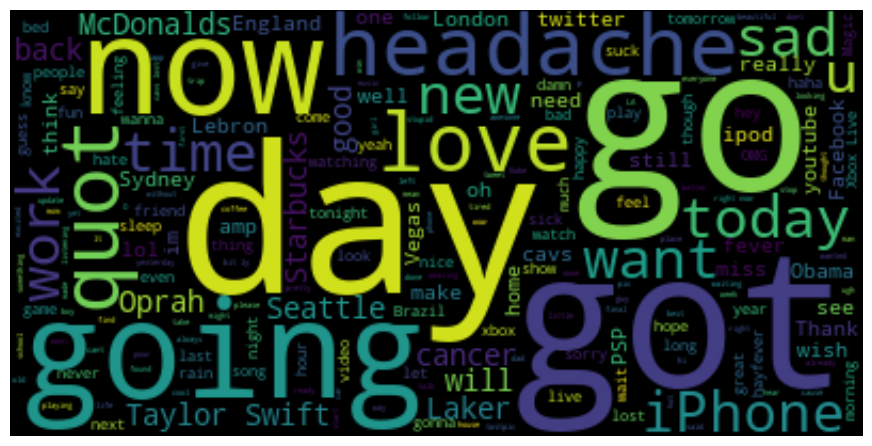

In [144]:
# Create and generate a word cloud image:
wordcloud = WordCloud().generate(words_dataset)

# Display the generated image:
plt.figure(figsize=(11,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [145]:
trainset.head(3)

,tweet,tweet_length,polarity
id,,,
2175019150,Facebook Make me SAD T.T,25,0
2174569897,Anyone using #TweetDeck? Their latest version...,119,0
1999078293,@JBsFanArgentina Hey I luv this pic!!! was ama...,91,4


In [146]:
raw_tokens_dataset = [ t for tweet in trainset.tweet for t in tweet.split() ]
raw_tokens_dataset[ : 10]

['Facebook',
 'Make',
 'me',
 'SAD',
 'T.T',
 'Anyone',
 'using',
 '#TweetDeck?',
 'Their',
 'latest']

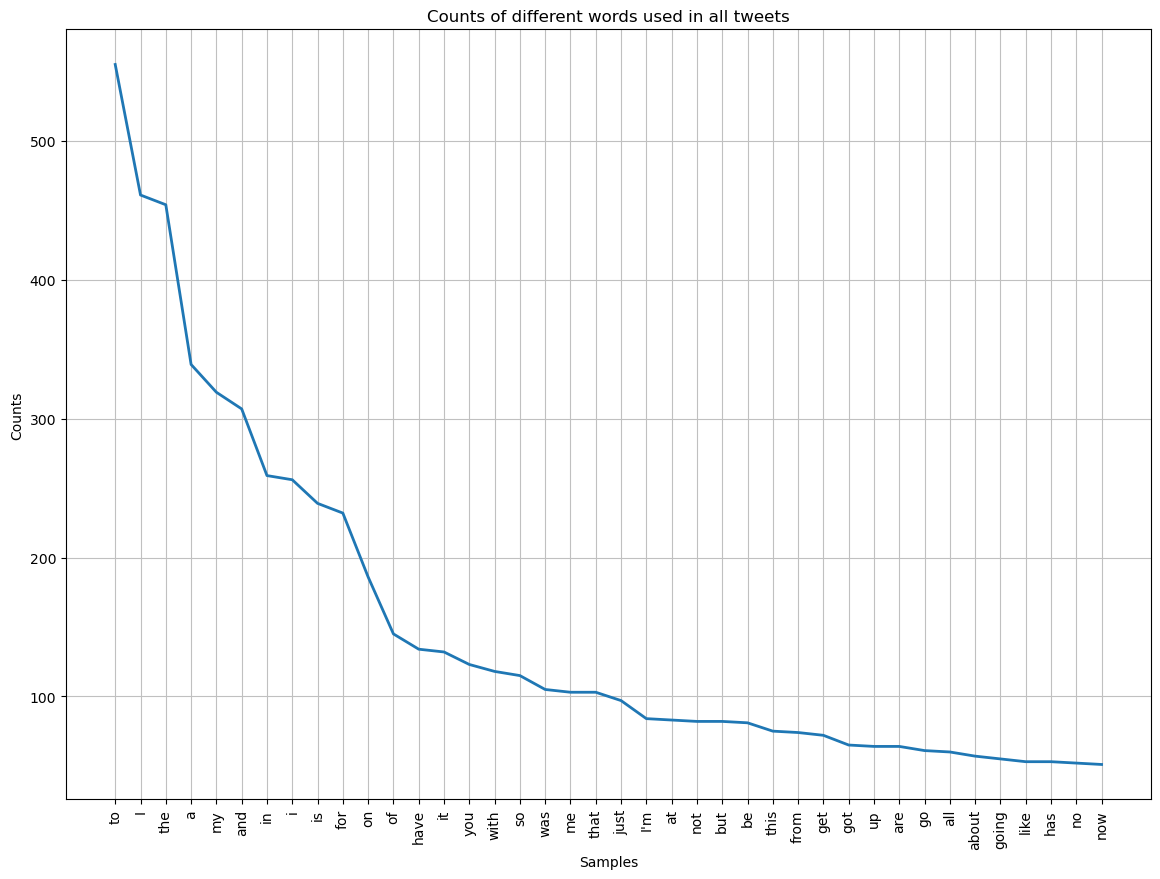

In [147]:
# Creating the word frequency distribution
freqdist = nltk.FreqDist(raw_tokens_dataset)

# Plotting the word frequency distribution
plt.figure(figsize=(14,10))
freqdist.plot(40,title='Counts of different words used in all tweets')

plt.show()

In [148]:
freqdist.most_common(40)

[('to', 555),
 ('I', 461),
 ('the', 454),
 ('a', 339),
 ('my', 319),
 ('and', 307),
 ('in', 259),
 ('i', 256),
 ('is', 239),
 ('for', 232),
 ('on', 186),
 ('of', 145),
 ('have', 134),
 ('it', 132),
 ('you', 123),
 ('with', 118),
 ('so', 115),
 ('was', 105),
 ('me', 103),
 ('that', 103),
 ('just', 97),
 ("I'm", 84),
 ('at', 83),
 ('not', 82),
 ('but', 82),
 ('be', 81),
 ('this', 75),
 ('from', 74),
 ('get', 72),
 ('got', 65),
 ('up', 64),
 ('are', 64),
 ('go', 61),
 ('all', 60),
 ('about', 57),
 ('going', 55),
 ('like', 53),
 ('has', 53),
 ('no', 52),
 ('now', 51)]

In [149]:
stop_words_keep = [ 'no', 'not', 'now', 'like', 'but', 'just' ]

In [150]:
stop_words = list( set(stopwords.words('english')) )
stop_words[ : 10]

["mightn't",
 'both',
 'as',
 'before',
 'we',
 'her',
 'once',
 'other',
 'such',
 "she'd"]

In [151]:
custom_stop_words = [ sw for sw in stop_words if sw not in stop_words_keep ]

In [152]:
trainset_positive = trainset [ trainset['polarity'] == 4 ]
trainset_negative = trainset [ trainset['polarity'] == 0 ]
trainset_positive.polarity.value_counts()

4    415
Name: polarity, dtype: int64

In [153]:
trainset_positive.head()

,tweet,tweet_length,polarity
id,,,
1999078293,@JBsFanArgentina Hey I luv this pic!!! was ama...,91,4
1932994382,"Just got back from market-market, bought the 8...",83,4
2190562741,"Had a piece of fried chicken, some PSP luv and...",63,4
1687934386,Seattle is sunny atm. Need to go take advant...,110,4
1467861393,@SwitchItNow ahhh shiner Bock in Austin YES! t...,95,4


In [154]:
trainset_positive_words = [ t for string in trainset_positive['tweet'] for t in string.split() ]
trainset_positive_words[ : 3]

['@JBsFanArgentina', 'Hey', 'I']

In [155]:
trainset_negative_words = [ t for string in trainset_negative['tweet'] for t in string.split() ]

In [156]:
trainset_positive_no_stop = [ word for word in trainset_positive_words if word.lower() not in custom_stop_words ]
trainset_negative_no_stop = [ word for word in trainset_negative_words if word.lower() not in custom_stop_words ]

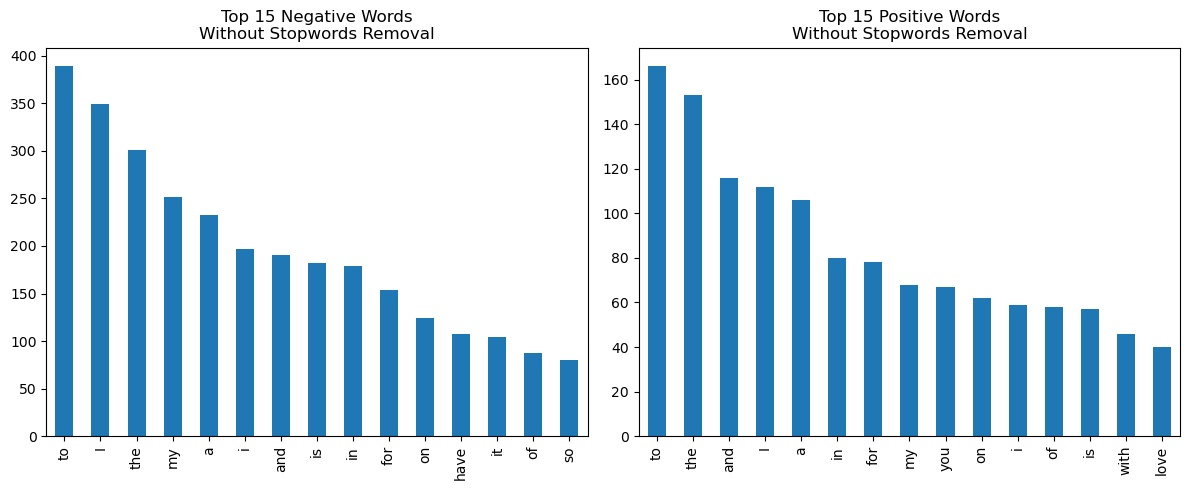

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Negative words
pd.Series(trainset_negative_words)\
    .value_counts()\
    .head(15)\
    .plot.bar(ax=axes[0], title="Top 15 Negative Words\nWithout Stopwords Removal")

# Positive words
pd.Series(trainset_positive_words)\
    .value_counts()\
    .head(15)\
    .plot.bar(ax=axes[1], title="Top 15 Positive Words\nWithout Stopwords Removal")

plt.tight_layout()
plt.show()

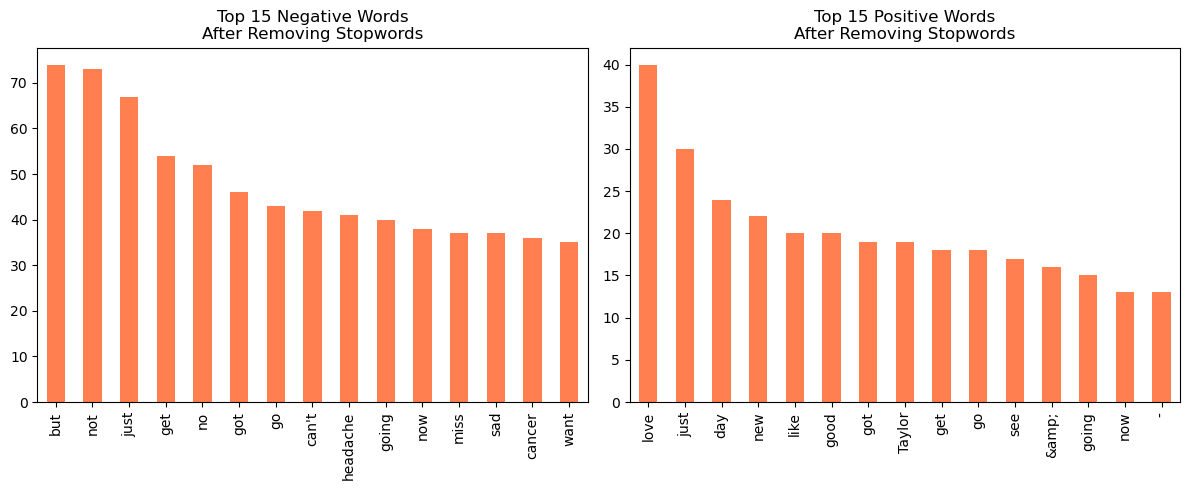

In [158]:
fig_two, axes_two = plt.subplots(1, 2, figsize=(12, 5))

# Negative words
pd.Series(trainset_negative_no_stop)\
    .value_counts()\
    .head(15)\
    .plot.bar(ax=axes_two[0], title="Top 15 Negative Words\nAfter Removing Stopwords", color = 'coral')

# Positive words
pd.Series(trainset_positive_no_stop)\
    .value_counts()\
    .head(15)\
    .plot.bar(ax=axes_two[1], title="Top 15 Positive Words\nAfter Removing Stopwords", color = 'coral')

plt.tight_layout()
plt.show()

In [159]:

pos_counts = pd.Series(trainset_positive_no_stop).value_counts()
neg_counts = pd.Series(trainset_negative_no_stop).value_counts()

# combine into one dataframe
df = pd.DataFrame({
    "pos": pos_counts,
    "neg": neg_counts
}).fillna(0)

# avoid division by zero
df["pos_ratio"] = (df["pos"] + 1) / (df["neg"] + 1)
df["neg_ratio"] = (df["neg"] + 1) / (df["pos"] + 1)

df.sort_values(by = 'pos_ratio', ascending = False).head()

,pos,neg,pos_ratio,neg_ratio
Thank,6.0,0.0,7.000000,0.142857
LOL,6.0,0.0,7.000000,0.142857
love,40.0,5.0,6.833333,0.146341
n,5.0,0.0,6.000000,0.166667
"awesome,",4.0,0.0,5.000000,0.200000


In [160]:
df.sort_values(by = 'neg_ratio', ascending = False).head()

,pos,neg,pos_ratio,neg_ratio
no,0.0,52.0,0.018868,53.0
headache,0.0,41.0,0.023810,42.0
sad,0.0,37.0,0.026316,38.0
fever,0.0,25.0,0.038462,26.0
bad,0.0,24.0,0.040000,25.0


In [161]:
df[[ 'pos_ratio', 'neg_ratio' ]].describe().round(2)

,pos_ratio,neg_ratio
count,5946.00,5946.00
mean,0.99,1.75
std,0.79,1.69
min,0.02,0.14
25%,0.50,0.50
50%,0.50,2.00
75%,2.00,2.00
max,7.00,53.00


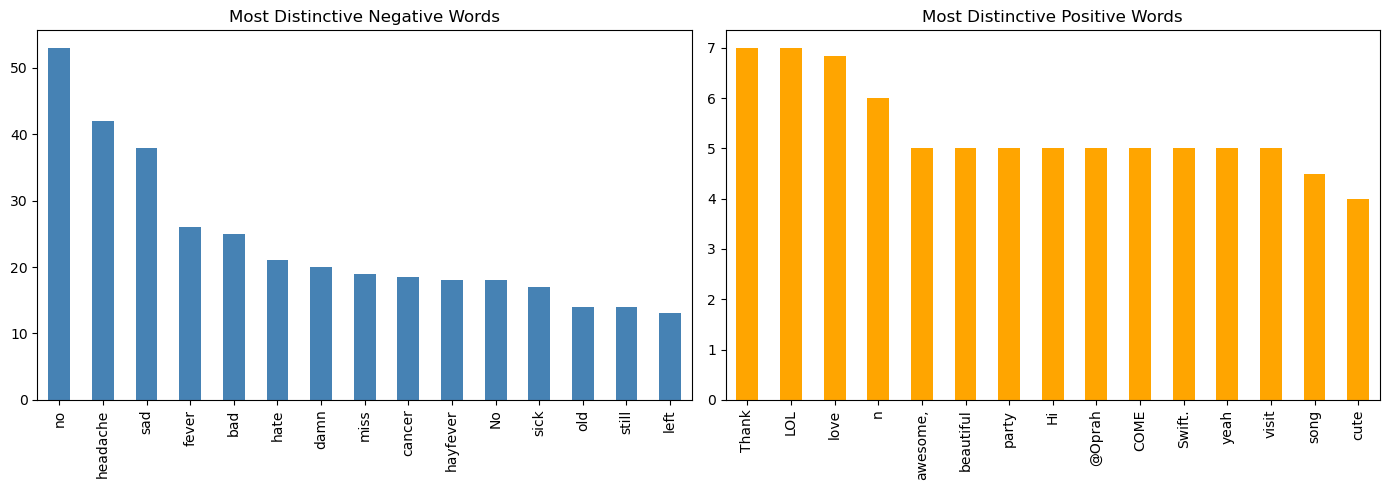

In [162]:
# top distinctive words
top_pos = df["pos_ratio"].sort_values(ascending=False).head(15)
top_neg = df["neg_ratio"].sort_values(ascending=False).head(15)

# plotting
fig, axes = plt.subplots(1, 2, figsize=(14,5))

top_neg.plot.bar(ax=axes[0], color="steelblue",
                 title="Most Distinctive Negative Words")

top_pos.plot.bar(ax=axes[1], color="orange",
                 title="Most Distinctive Positive Words")

plt.tight_layout()
plt.show()

In [163]:
X_train, X_test, y_train, y_test = trainset.drop(['polarity', 'tweet_length'], axis = 1), testset.drop(['polarity', 'tweet_length'], axis = 1),\
trainset['polarity'], testset['polarity']

In [164]:
y_train = y_train.map({0 : 0, 4 : 1}) 
y_test = y_test.map({0 : 0, 4 : 1}) 

In [165]:
X_train.head()

,tweet
id,
2175019150,Facebook Make me SAD T.T
2174569897,Anyone using #TweetDeck? Their latest version...
1999078293,@JBsFanArgentina Hey I luv this pic!!! was ama...
2228191539,"uh oh, Dr. Phil just made me cry and it looks ..."
1468055604,And somehow I still end up in this place


In [166]:
y_train.head()

id
2175019150    0
2174569897    0
1999078293    1
2228191539    0
1468055604    0
Name: polarity, dtype: int64

In [167]:
vader = SentimentIntensityAnalyzer()


print( vader.polarity_scores('I love you'), '\n' )
print( vader.polarity_scores('I hate you') )

{'neg': 0.0, 'neu': 0.192, 'pos': 0.808, 'compound': 0.6369} 

{'neg': 0.787, 'neu': 0.213, 'pos': 0.0, 'compound': -0.5719}


In [168]:
X_train['vader_score'] = X_train['tweet'].map( vader.polarity_scores ).str.get('compound')
X_test['vader_score'] = X_test['tweet'].map( vader.polarity_scores ).str.get('compound')

X_train.head()

,tweet,vader_score
id,,
2175019150,Facebook Make me SAD T.T,-0.5904
2174569897,Anyone using #TweetDeck? Their latest version...,-0.1695
1999078293,@JBsFanArgentina Hey I luv this pic!!! was ama...,0.7156
2228191539,"uh oh, Dr. Phil just made me cry and it looks ...",-0.1531
1468055604,And somehow I still end up in this place,0.0000


In [169]:
def perform_vader_sentiment_evaluation(frame, documents_col = 'tweet', prediction=True,\
                                       overall_score=True, full_scores=False, treshold = 0) :

    frame = frame.copy()

    vader = SentimentIntensityAnalyzer()

    scores = frame[documents_col].map(vader.polarity_scores)

    if overall_score:
        frame['vader_score'] = scores.str.get('compound')

    if full_scores:
        scores_df = pd.json_normalize(scores)
        scores_df.columns = [f'vader_{c}' for c in scores_df.columns]
        frame = pd.concat([frame, scores_df], axis=1)

    if prediction:
        if 'vader_score' not in frame:
            frame['vader_score'] = scores.str.get('compound')

        frame['vader_prediction'] = frame['vader_score'].apply(
            lambda x: 1 if x > treshold
            else 0
        )

    return frame

In [170]:
vader_train = perform_vader_sentiment_evaluation( X_train )
vader_train.head()

,tweet,vader_score,vader_prediction
id,,,
2175019150,Facebook Make me SAD T.T,-0.5904,0
2174569897,Anyone using #TweetDeck? Their latest version...,-0.1695,0
1999078293,@JBsFanArgentina Hey I luv this pic!!! was ama...,0.7156,1
2228191539,"uh oh, Dr. Phil just made me cry and it looks ...",-0.1531,0
1468055604,And somehow I still end up in this place,0.0000,0


In [171]:
vader_prediction_train = vader_train['vader_prediction']

In [172]:
vader_test = perform_vader_sentiment_evaluation( X_test )
vader_test.head()

,tweet,vader_score,vader_prediction
id,,,
1467970787,"ready for nice weather, day drinking &amp; not...",0.6486,1
2066535902,starbucks &amp; tanning. good start for today,0.4404,1
1467890723,Is terrified she accidentally deleted a refere...,-0.3274,0
1468006981,I wonder what jon thinks when he see's all his...,0.4939,1
2053125094,whywhywhy do Rookie Of The Year not come to En...,0.0000,0


In [173]:
vader_prediction_test = vader_test['vader_prediction']

In [174]:
train_acc = accuracy_score(y_train, vader_prediction_train)
test_acc = accuracy_score(y_test, vader_prediction_test)

print(f"Train accuracy is {train_acc:.3f}")
print(f"Test accuracy is {test_acc:.3f}")

Train accuracy is 0.789
Test accuracy is 0.768


In [175]:
from sklearn.metrics import classification_report

print("Train report")
print(classification_report(y_train, vader_prediction_train))

print("Test report")
print(classification_report(y_test, vader_prediction_test))

Train report
              precision    recall  f1-score   support

           0       0.90      0.78      0.84       947
           1       0.62      0.80      0.70       415

    accuracy                           0.79      1362
   macro avg       0.76      0.79      0.77      1362
weighted avg       0.81      0.79      0.79      1362

Test report
              precision    recall  f1-score   support

           0       0.88      0.76      0.82       455
           1       0.61      0.79      0.69       217

    accuracy                           0.77       672
   macro avg       0.75      0.77      0.75       672
weighted avg       0.80      0.77      0.77       672



In [176]:
y_test.head()

id
1467970787    0
2066535902    1
1467890723    0
1468006981    1
2053125094    0
Name: polarity, dtype: int64

In [177]:
y_train.head()

id
2175019150    0
2174569897    0
1999078293    1
2228191539    0
1468055604    0
Name: polarity, dtype: int64

In [178]:
X_train.head()

,tweet,vader_score
id,,
2175019150,Facebook Make me SAD T.T,-0.5904
2174569897,Anyone using #TweetDeck? Their latest version...,-0.1695
1999078293,@JBsFanArgentina Hey I luv this pic!!! was ama...,0.7156
2228191539,"uh oh, Dr. Phil just made me cry and it looks ...",-0.1531
1468055604,And somehow I still end up in this place,0.0000


In [179]:
X_train_ML = X_train.drop('vader_score', axis = 1)
X_test_ML = X_test.drop('vader_score', axis = 1)

In [181]:
X_train_ML.head()

,tweet
id,
2175019150,Facebook Make me SAD T.T
2174569897,Anyone using #TweetDeck? Their latest version...
1999078293,@JBsFanArgentina Hey I luv this pic!!! was ama...
2228191539,"uh oh, Dr. Phil just made me cry and it looks ..."
1468055604,And somehow I still end up in this place


In [189]:
X_test_ML.tweet.sample(n = 5)

id
2179230597    @flyknocka after all these years and working a...
2068801318    great weekend w/family &amp; friends.  PUMP wa...
1467969583    Rye143gg (1:58:00 AM): Lol. Ur really pretty.....
1548615776    @bbrannan I'm and good and glad you are too!  ...
2199363383                           Xbox live is down today.  
Name: tweet, dtype: object

In [190]:
type(X_test_ML.tweet)

pandas.core.series.Series

In [199]:
def run_experiment(X_train, X_test, y_train, y_test, vectorizer, stopwords=None, model=None):

    if model is None:
        model = LogisticRegression()

    pipe = Pipeline([
        ("vec", vectorizer( stop_words=stopwords, ngram_range = (1, 2) ) ),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    pred_train = pipe.predict(X_train)
    pred_test = pipe.predict(X_test)

    return {
        "train_acc": accuracy_score(y_train, pred_train),
        "test_acc": accuracy_score(y_test, pred_test),
        "test_precision": precision_score(y_test, pred_test),
        "test_recall": recall_score(y_test, pred_test),
        "test_f1": f1_score(y_test, pred_test)
    }


models = [
    ("LogReg", LogisticRegression()),
    ("LinearSVC", LinearSVC())
]

configs = [
    ("TF", CountVectorizer, None),
    ("TF + stopwords removal", CountVectorizer, custom_stop_words),
    ("TFIDF", TfidfVectorizer, None),
    ("TFIDF + stopwords removal", TfidfVectorizer, custom_stop_words)
]

results = []

for model_name, model in models:
    
    for vec_name, vectorizer, stopwords in configs:
        
        res = run_experiment(
            X_train_ML[ 'tweet' ],
            X_test_ML[ 'tweet' ],
            y_train,
            y_test,
            vectorizer,
            stopwords=stopwords,
            model=model
        )
        
        res["model"] = model_name
        res["vectorizer"] = vec_name
        
        results.append(res)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values("test_f1", ascending=False)

results_df


,train_acc,test_acc,test_precision,test_recall,test_f1,model,vectorizer
7,1.000000,0.828869,0.800000,0.626728,0.702842,LinearSVC,TFIDF + stopwords removal
4,1.000000,0.824405,0.807453,0.599078,0.687831,LinearSVC,TF
6,1.000000,0.825893,0.847222,0.562212,0.675900,LinearSVC,TFIDF
5,1.000000,0.812500,0.772455,0.594470,0.671875,LinearSVC,TF + stopwords removal
0,1.000000,0.825893,0.878788,0.534562,0.664756,LogReg,TF
1,0.999266,0.809524,0.839695,0.506912,0.632184,LogReg,TF + stopwords removal
3,0.823054,0.758929,0.898551,0.285714,0.433566,LogReg,TFIDF + stopwords removal
2,0.820117,0.758929,0.936508,0.271889,0.421429,LogReg,TFIDF
